In [1]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm.autonotebook import tqdm

C:\Users\oyelola Ibrahim\AppData\Local\Temp\ipykernel_20836\1761360250.py:9: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
annotations = pd.read_csv("key_points.csv")
annotations.columns = [i.lower() for i in annotations.columns]
annotations.dropna(axis=0, inplace=True)
selected_images = set(annotations["img_name"].values)

In [3]:
annotations

,img_name,outer left eyebrow x,outer left eyebrow y,inner left eyebrow x,inner left eyebrow y,inner right eyebrow x,inner right eyebrow y,outer right eyebrow x,outer right eyebrow y,left eye left corner x,...,left eye iris x,left eye iris y,right eye iris x,right eye iris y,left eyebrow upper left corner x,left eyebrow upper left corner y,left eyebrow upper right corner x,left eyebrow upper right corner y,left eyebrow lower right corner x,left eyebrow lower right corner y
0,00004.png,128.0,237.0,130.0,276.0,136.0,313.0,145.0,349.0,159.0,...,253.0,390.0,268.0,388.0,294.0,386.0,268.0,395.0,253.0,397.0
1,00023.png,113.0,247.0,112.0,286.0,111.0,326.0,117.0,363.0,131.0,...,251.0,356.0,272.0,354.0,309.0,361.0,272.0,379.0,251.0,382.0
2,00024.png,201.0,254.0,195.0,279.0,192.0,307.0,197.0,335.0,205.0,...,225.0,382.0,238.0,381.0,281.0,382.0,239.0,384.0,226.0,384.0
3,00033.png,8.0,266.0,18.0,318.0,29.0,368.0,46.0,414.0,81.0,...,292.0,371.0,302.0,370.0,308.0,382.0,298.0,403.0,288.0,406.0
4,00041.png,124.0,213.0,129.0,252.0,137.0,289.0,144.0,326.0,155.0,...,254.0,384.0,267.0,382.0,297.0,383.0,266.0,387.0,253.0,389.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1417,53858.png,98.0,232.0,101.0,273.0,108.0,311.0,116.0,349.0,132.0,...,256.0,373.0,277.0,369.0,318.0,354.0,277.0,377.0,256.0,381.0
1420,53893.png,90.0,220.0,95.0,263.0,103.0,304.0,113.0,342.0,127.0,...,262.0,379.0,275.0,376.0,309.0,368.0,275.0,378.0,261.0,380.0
1421,53924.png,109.0,210.0,109.0,251.0,113.0,292.0,122.0,329.0,141.0,...,259.0,381.0,275.0,378.0,306.0,366.0,275.0,378.0,259.0,382.0
1422,53962.png,79.0,254.0,82.0,293.0,87.0,331.0,97.0,370.0,115.0,...,274.0,375.0,287.0,374.0,306.0,381.0,287.0,390.0,274.0,391.0


In [4]:
data_path_1 = "C:/Users/oyelola Ibrahim/Desktop/Facial keypoint/dataset_1"
data_path_2 = "C:/Users/oyelola Ibrahim/Desktop/Facial keypoint/dataset_2"

path_1_images = list(set(os.listdir(data_path_1)).intersection(selected_images))
path_2_images = list(set(os.listdir(data_path_2)).intersection(selected_images))

class Config:
    num_train_samples = 1200
    num_val_samples = len(path_1_images) + len(path_2_images) - num_train_samples
    train_batch_size = 5
    val_batch_size = 5
    epochs = 5
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    lr = 1e-5

train_data_list = (
    list(map(lambda x: os.path.join(data_path_1, x), path_1_images)) +
    list(map(lambda x: os.path.join(data_path_2, x), path_2_images[:len(path_2_images) - Config.num_val_samples]))
)
val_data_list = list(map(lambda x: os.path.join(data_path_2, x), path_2_images[len(path_2_images) - Config.num_val_samples:]))

class FaceData(Dataset):  
    def __init__(self, data, annotations, transforms=None):
        self.transforms = transforms
        self.data = data
        self.annotations = annotations

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        data = self.data[idx]
        img_name = os.path.basename(data)  
        labels = torch.tensor(
            self.annotations.loc[self.annotations['img_name'] == img_name].iloc[:, 1:].values.reshape(-1, 2),
            dtype=torch.float32
        )
        image = Image.open(data).convert("RGB") 
        if self.transforms is not None:
            image = self.transforms(image)
        return {"x": image, "y": labels}

image_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)
])

train_data = FaceData(train_data_list, annotations, image_transforms)
val_data   = FaceData(val_data_list, annotations, image_transforms)
train_loader = DataLoader(train_data, Config.train_batch_size, shuffle=True)
val_loader   = DataLoader(val_data, Config.val_batch_size)

In [5]:
next(iter(train_loader))["y"].shape

torch.Size([5, 67, 2])

In [6]:
class KeypointModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=True)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=True)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1, bias=True)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(128 * 64 * 64, 512, bias=True)
        self.relu4 = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(512, 67 * 2, bias=True)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = x.view(-1, 128 * 64 * 64)
        x = self.relu4(self.fc1(x))
        x = self.fc2(x).view(-1, 67, 2)
        return x

In [7]:
model = KeypointModel()
model = model.to(device=Config.device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=Config.lr)

avg_train_loss = []
avg_val_loss = []

for epoch in tqdm(range(Config.epochs)):
    model.train()
    train_loss = 0
    for batch in train_loader:
        X = batch['x'].to(device=Config.device)
        Y = batch['y'].to(device=Config.device)
        optimizer.zero_grad() 
        out = model(X)
        loss = criterion(out, Y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    with torch.no_grad():
        val_loss = 0
        for batch in val_loader:
            x = batch['x'].to(device=Config.device)
            y = batch['y'].to(device=Config.device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item()
        val_loss /= len(val_loader)

    avg_train_loss.append(train_loss)
    avg_val_loss.append(val_loss)
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

 20%|██        | 1/5 [33:20<2:13:23, 2000.94s/it]

Epoch 1: train_loss=43372.3834, val_loss=4384.0370


 40%|████      | 2/5 [1:04:23<1:35:59, 1919.80s/it]

Epoch 2: train_loss=2994.8907, val_loss=1862.3814


 60%|██████    | 3/5 [10:55:58<9:35:01, 17250.68s/it]

Epoch 3: train_loss=1369.8408, val_loss=742.9187


 80%|████████  | 4/5 [14:55:15<4:28:28, 16108.50s/it]

Epoch 4: train_loss=633.4891, val_loss=534.3291


100%|██████████| 5/5 [17:52:50<00:00, 12874.16s/it]  

Epoch 5: train_loss=466.0604, val_loss=441.4240


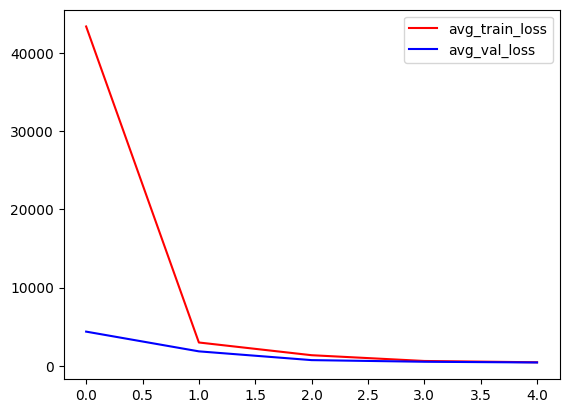

In [8]:
import matplotlib.pyplot as plt
plt.plot(range(len(avg_train_loss)), avg_train_loss, '-r')
plt.plot(range(len(avg_val_loss)), avg_val_loss, '-b')
plt.legend(['avg_train_loss', 'avg_val_loss'])

In [10]:
def plot_preds(model, image_path):
    from PIL import ImageDraw
    import torchvision.transforms.functional as tf
    im = Image.open(image_path).convert("RGB")  
    tensor = tf.to_tensor(im).unsqueeze(0)       
    with torch.no_grad():
        out = model(tensor.to(device=Config.device))
    for feature in out[0]:
        x, y = feature[0].item(), feature[1].item()
        draw.ellipse((x-2, y-2, x+2, y+2), fill=(255, 0, 0))
    return im